#  Marketing Campaign Analysis & Budget Optimization

## Executive Summary

###  Project Objective
The objective of this project is to analyze customer behavior and marketing campaign performance to predict customer conversion using Machine Learning. Additionally, the project aims to identify the key business factors influencing conversions and provide data-driven recommendations for optimizing marketing budget allocation.

---

###  Dataset Overview

- **Dataset Size:** 8,000 customer records
- **Total Features:** 20 (including the target variable)
- **Target Variable:** `Conversion`
- **Problem Type:** Binary Classification

The dataset contains customer demographics, campaign information, website engagement metrics, email interaction, purchase history, advertising platforms, and conversion outcomes.

---

###  Project Workflow

✔ Data Cleaning & Preprocessing

✔ Exploratory Data Analysis (EDA)

✔ KPI Engineering

✔ Customer Segmentation & Behavioral Analysis

✔ Feature Engineering

✔ Machine Learning Model Development

✔ Model Evaluation & Comparison

✔ Hyperparameter Tuning (RandomizedSearchCV)

✔ Cross Validation

✔ Feature Importance Analysis

✔ SHAP Explainability

✔ Business Recommendations

✔ Model Saving & Deployment using Streamlit

---

###  Machine Learning Models Evaluated

- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

The best-performing model was selected based on evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

---

###  Business Goal

This project enables organizations to:

- Predict customers who are most likely to convert.
- Identify the key drivers influencing customer conversion.
- Improve campaign effectiveness using explainable AI.
- Optimize marketing budget allocation across different campaign channels.
- Support data-driven decision-making through actionable business recommendations.

# 📑 Table of Contents

1. Project Overview
2. Importing Libraries
3. Loading the Dataset
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Feature Engineering
7. Model Building
8. Hyperparameter Tuning
9. Model Evaluation using SHAP
10. Model Explainability
11. Budget Optimization & Business Insights
12. Model Saving
13. Conclusion
14. Future Scope

#1. Importing Libraries

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.impute import SimpleImputer
import shap
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

#2. Loading Dataset

In [412]:
df=pd.read_csv("/content/digital_marketing_campaign_dataset.csv.zip")

#3. Data Inspection

In [413]:
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [415]:
df.shape

(8000, 20)

In [416]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


#4. Data Cleaning

In [417]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
CampaignChannel,0
CampaignType,0
AdSpend,0
ClickThroughRate,0
ConversionRate,0
WebsiteVisits,0


In [418]:
df.drop(columns=['CustomerID'], inplace=True) # has no use in data set

In [419]:
df.head(2)

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1


In [420]:
df.duplicated().sum() # Checking that there are no duplicates

np.int64(0)

In [421]:
# AdvertisingPlatform and AdvertisingTool doesn't provide any information to us and are of no use , so droping these
df.drop(columns=['AdvertisingPlatform', 'AdvertisingTool'], inplace=True)

In [422]:
df.head(2)

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1


In [423]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns
print(num_cols)
print(cat_cols)

Index(['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'Conversion'],
      dtype='object')
Index(['Gender', 'CampaignChannel', 'CampaignType'], dtype='object')


In [424]:
# checking what all unique values each column has

for col in cat_cols:
    print(df[col].value_counts())
    print("-"*50)

Gender
Female    4839
Male      3161
Name: count, dtype: int64
--------------------------------------------------
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64
--------------------------------------------------
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64
--------------------------------------------------


In [425]:
df['Age'].describe() # There are no ages < 0

,Age
count,8000.000000
mean,43.625500
std,14.902785
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


In [426]:
df['AdSpend'].describe()  # NO negative ad spend

,AdSpend
count,8000.000000
mean,5000.944830
std,2838.038153
min,100.054813
25%,2523.221165
50%,5013.440044
75%,7407.989369
max,9997.914781


# Insights:
The dataset contains clean, complete customer journey data without missing values, reducing preprocessing overhead and improving modeling reliability.

In [427]:
df['EngagementScore'] = (
    df['WebsiteVisits']
    + df['PagesPerVisit']
    + df['TimeOnSite']
    + df['SocialShares']
    + df['EmailOpens']
    + df['EmailClicks']
)

#5. Exploratory Data Analysis (EDA)

### Univariate analysis

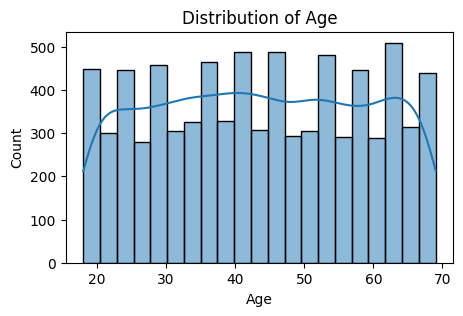

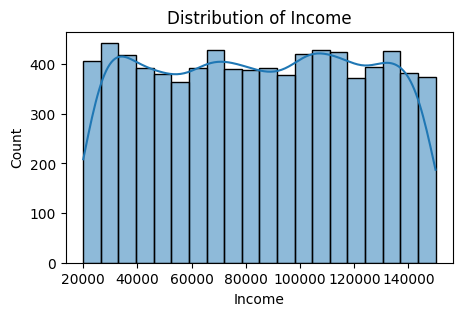

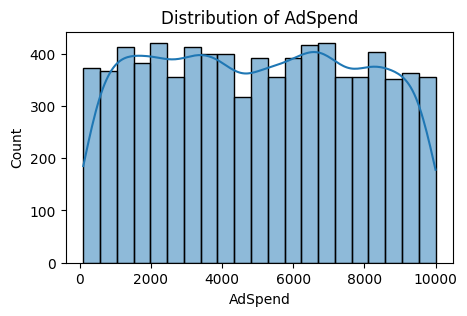

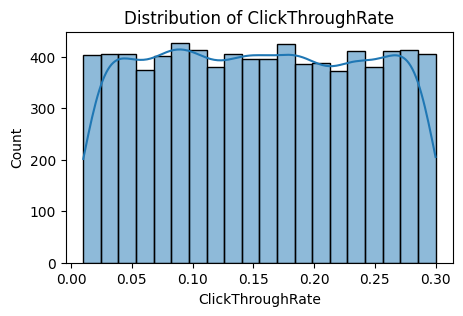

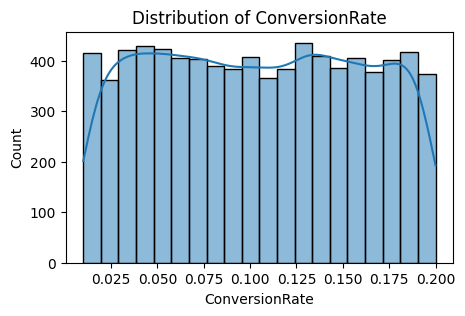

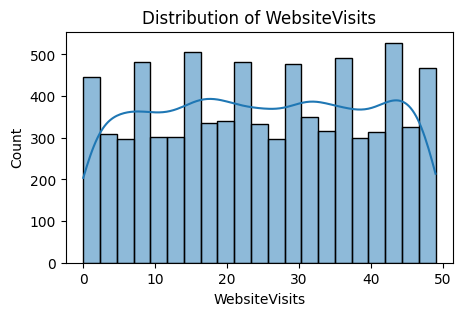

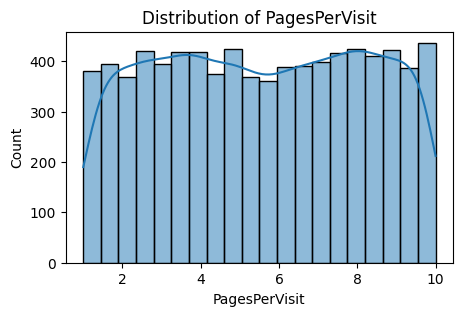

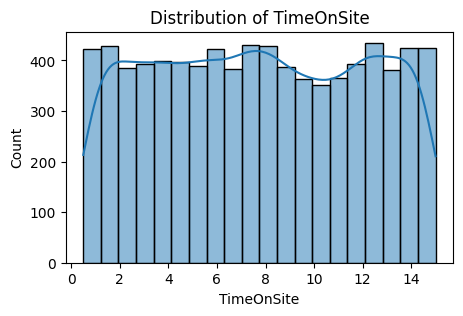

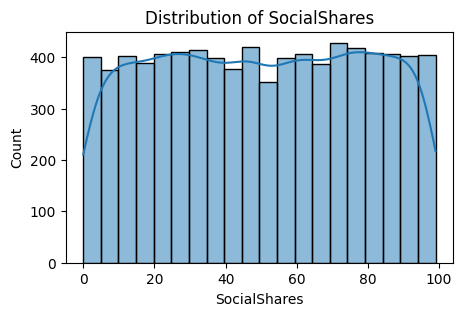

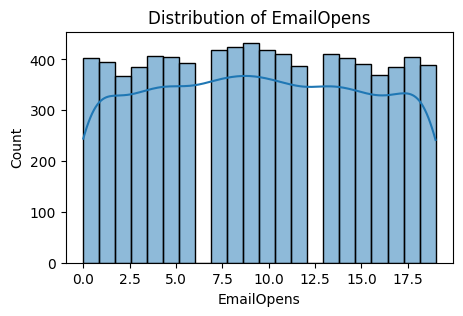

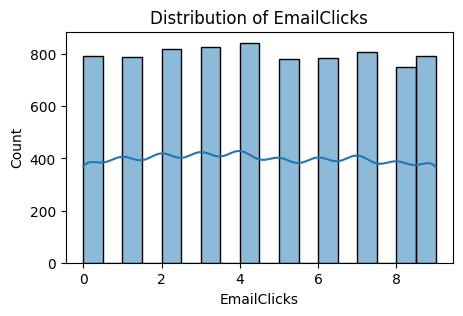

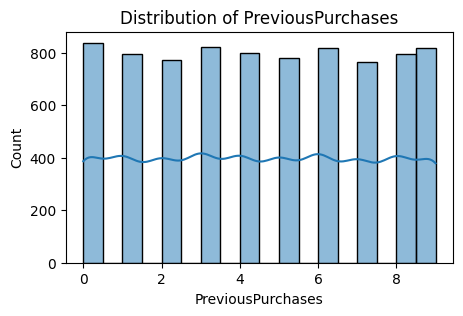

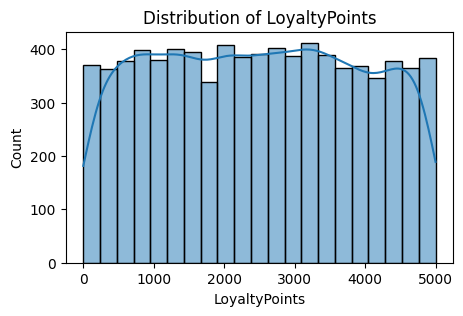

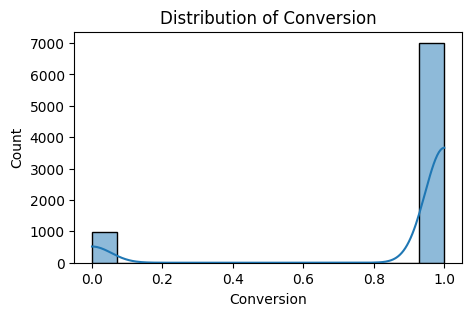

In [428]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

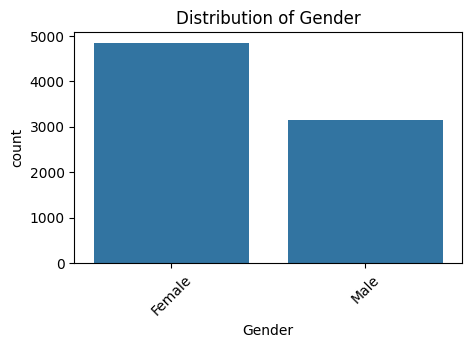

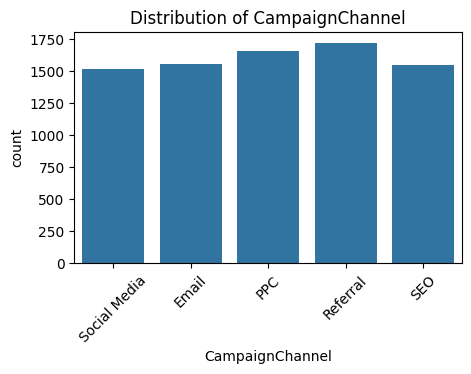

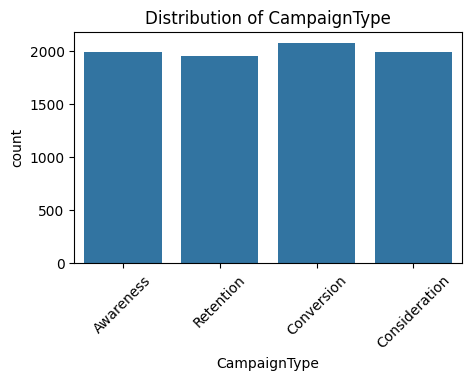

In [429]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()

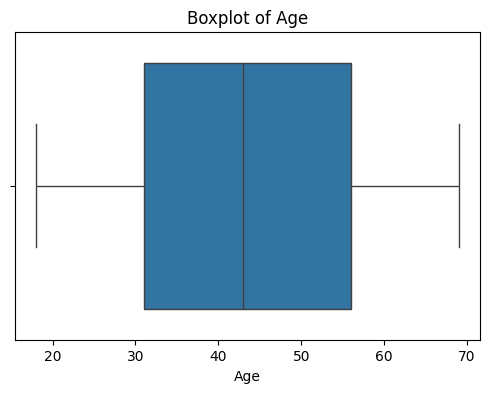

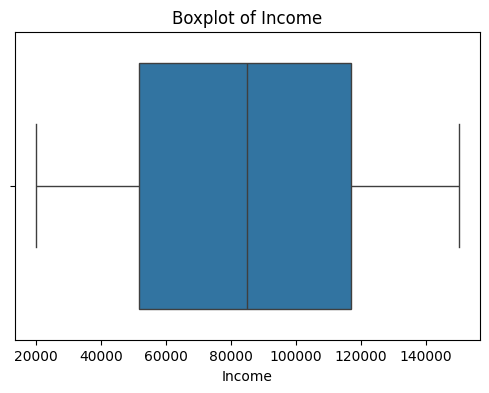

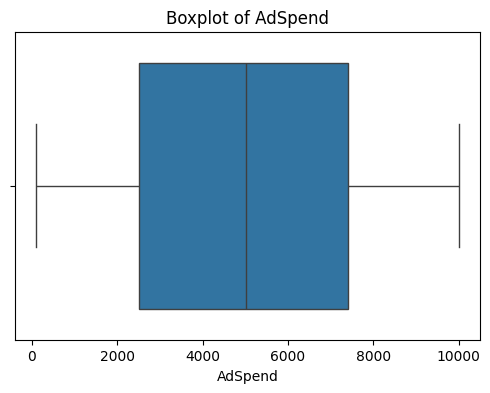

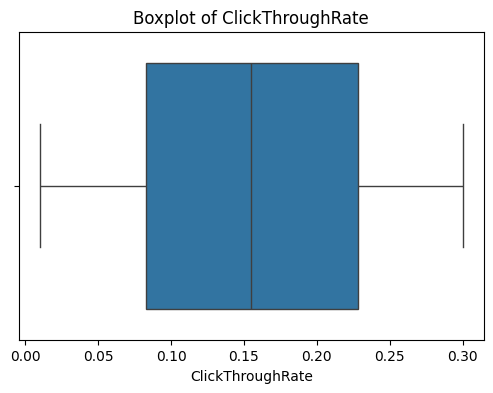

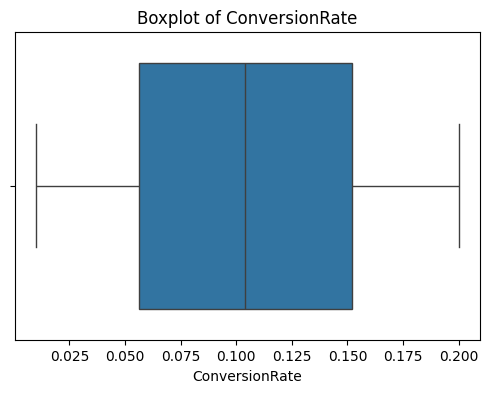

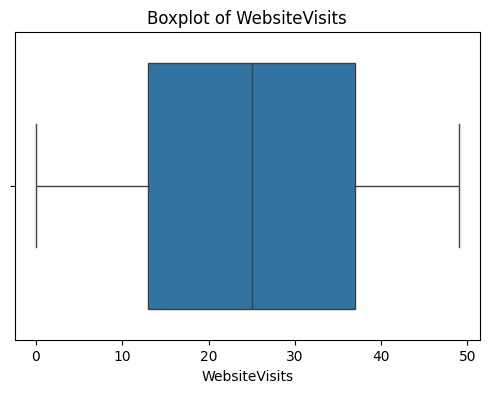

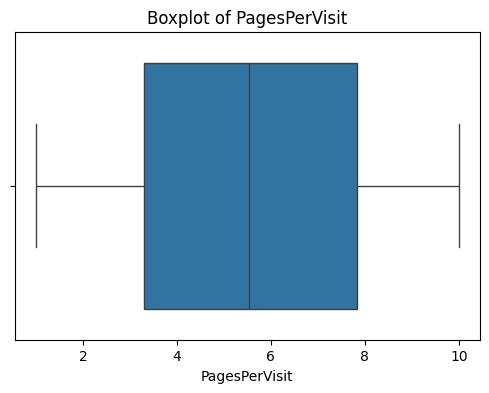

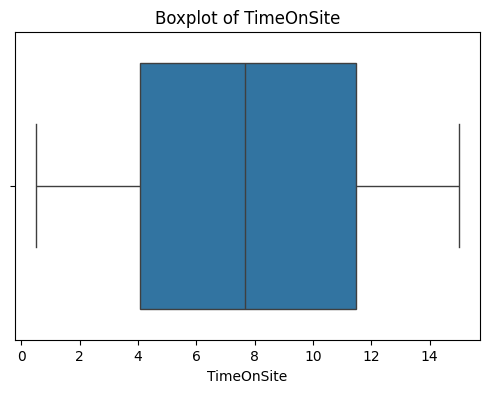

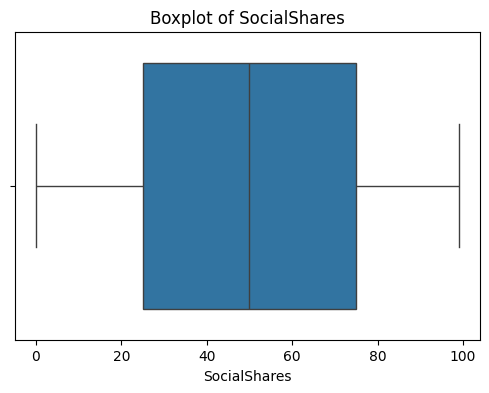

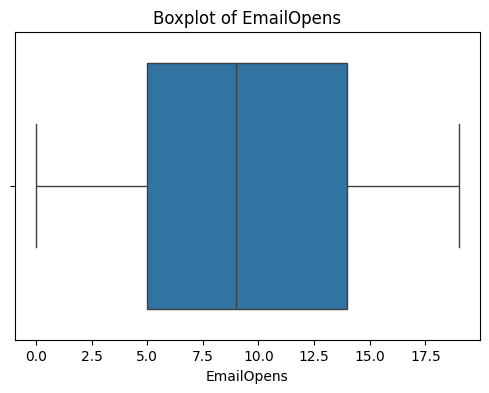

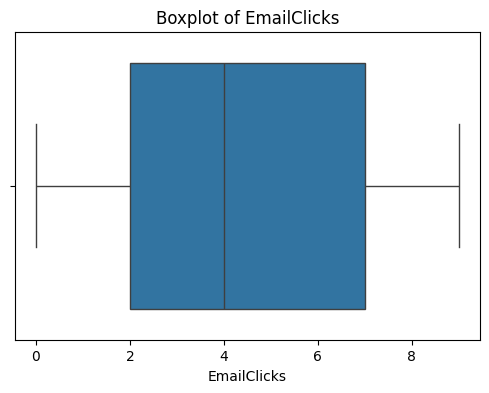

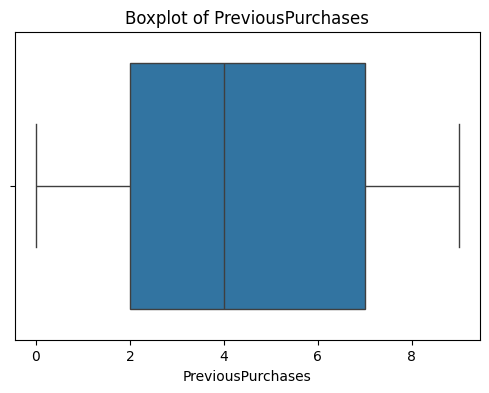

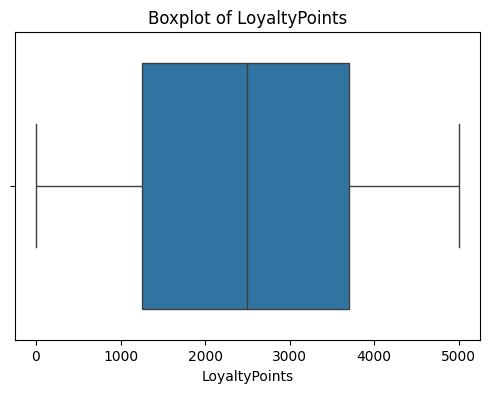

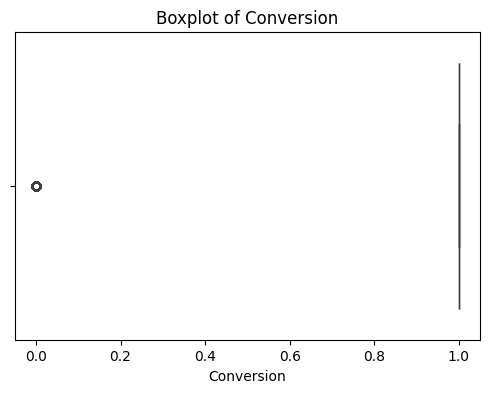

In [430]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [431]:
df['Conversion'].value_counts()

,count
Conversion,
1,7012
0,988


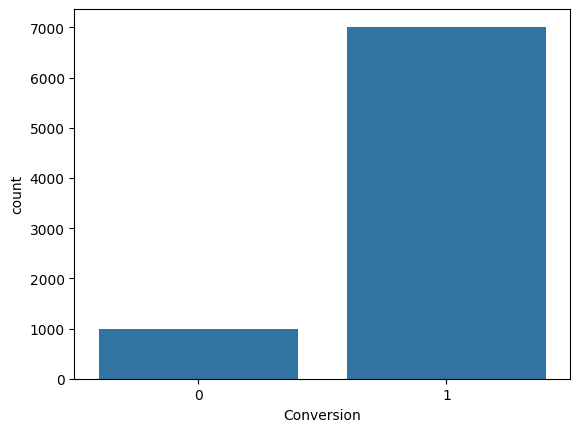

In [432]:
sns.countplot(data=df, x='Conversion')
plt.show()

### Bivariate analysis

In [433]:
conversion_analysis = (
    df.groupby('Conversion')
      .mean(numeric_only=True)
)
print(conversion_analysis)

                  Age        Income      AdSpend  ClickThroughRate  \
Conversion                                                           
0           43.561741  83265.308704  4058.398466          0.127972   
1           43.634484  84861.301911  5133.750850          0.158613   

            ConversionRate  WebsiteVisits  PagesPerVisit  TimeOnSite  \
Conversion                                                             
0                 0.090766      21.726721       4.835002    6.267871   
1                 0.106308      25.177838       5.649945    7.933413   

            SocialShares  EmailOpens  EmailClicks  PreviousPurchases  \
Conversion                                                             
0              50.681174    7.576923     3.481781           3.625506   
1              49.675556    9.744581     4.606246           4.606674   

            LoyaltyPoints  EngagementScore  
Conversion                                  
0             2128.483806        94.569472  
1     

| Metric            | % Change in Converters |
| ----------------- | ---------------------- |
| AdSpend           | +26%                   |
| CTR               | +24%                   |
| WebsiteVisits     | +16%                   |
| PagesPerVisit     | +17%                   |
| TimeOnSite        | +27%                   |
| EmailOpens        | +28%                   |
| EmailClicks       | +32%                   |
| PreviousPurchases | +27%                   |
| LoyaltyPoints     | +19%                   |



### Strongest positive indicators of conversion:
* Estimated Clicks (+47%)
* Email Clicks (+32%)
* Email Opens (+28%)
* Time On Site (+27%)
* Previous Purchases (+27%)
* Ad Spend (+26%)
### Weak indicators:
* Age
* Income
* Social Shares
### Strategic Recommendations:
* Increase investment in email campaigns.
* Prioritize retention and loyalty programs.
* Improve website engagement and session duration.
* Scale campaigns achieving low CPC and high click generation.
* Focus on behavioural metrics rather than demographic targeting.

### Correlation Analysis

<Axes: >

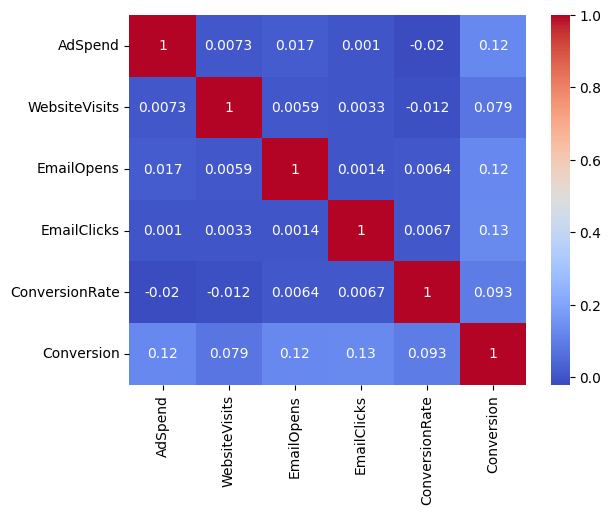

In [434]:
cols = [
    'AdSpend',
    'WebsiteVisits',
    'EmailOpens',
    'EmailClicks',
    'ConversionRate',
    'Conversion'
]

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='coolwarm'
)

* There are almost no correlation between any variables, as most values are near 0.
* Customer conversion is probably driven by a combination of multiple factors rather than any single metric


### Campaign Performance Analysis

In [435]:
# Campaign Type Dashboard

campaign_dashboard = (
    df.groupby('CampaignType')
      .agg(
          Total_Spend=('AdSpend', 'sum'),
          Avg_CTR=('ClickThroughRate', 'mean'),
          Avg_Conversion_Rate=('ConversionRate', 'mean'),
          Total_Conversions=('Conversion', 'sum')
      )
)

campaign_dashboard['CAC'] = (
    campaign_dashboard['Total_Spend']
    / campaign_dashboard['Total_Conversions']
)

print("\nCampaign Type Dashboard")
print(campaign_dashboard)


Campaign Type Dashboard
                Total_Spend   Avg_CTR  Avg_Conversion_Rate  Total_Conversions  \
CampaignType                                                                    
Awareness      1.007785e+07  0.155764             0.104372               1701   
Consideration  9.861274e+06  0.151798             0.105069               1701   
Conversion     1.030008e+07  0.155665             0.104859               1939   
Retention      9.768362e+06  0.156076             0.103210               1671   

                       CAC  
CampaignType                
Awareness      5924.659510  
Consideration  5797.339021  
Conversion     5312.056205  
Retention      5845.818169  


In [436]:
# Channel Performance Dashboard

channel_dashboard = (
    df.groupby('CampaignChannel')
      .agg(
          Total_Spend=('AdSpend', 'sum'),
          Avg_CTR=('ClickThroughRate', 'mean'),
          Avg_Conversion_Rate=('ConversionRate', 'mean'),
          Total_Conversions=('Conversion', 'sum')
      )
)

channel_dashboard['CAC'] = (
    channel_dashboard['Total_Spend']
    / channel_dashboard['Total_Conversions']
)

print("\nChannel Dashboard")
print(channel_dashboard)


Channel Dashboard
                  Total_Spend   Avg_CTR  Avg_Conversion_Rate  \
CampaignChannel                                                
Email            7.871576e+06  0.155609             0.104884   
PPC              8.199237e+06  0.158307             0.104132   
Referral         8.653519e+06  0.151673             0.103051   
SEO              7.740904e+06  0.153150             0.103530   
Social Media     7.542323e+06  0.155523             0.106550   

                 Total_Conversions          CAC  
CampaignChannel                                  
Email                         1355  5809.281071  
PPC                           1461  5612.071856  
Referral                      1518  5700.605195  
SEO                           1359  5696.029342  
Social Media                  1319  5718.213229  


### Customer Segmentation Analysis

/tmp/ipykernel_2970/2976103765.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Conversion']


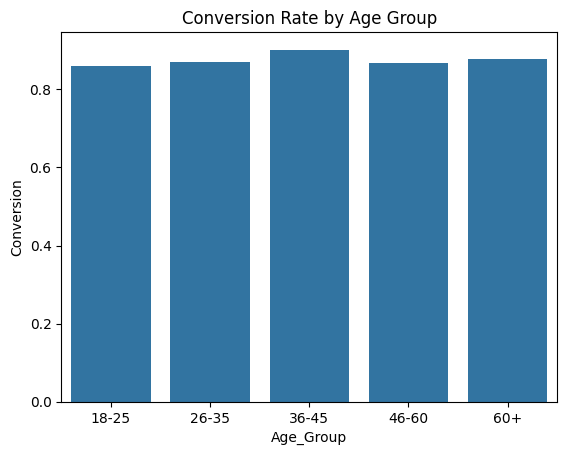

In [437]:
# 1.Age group Vs Conversion
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60, 100],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
)

age_conv = (
    df.groupby('Age_Group')['Conversion']
      .mean()
      .reset_index()
)

sns.barplot(data=age_conv, x='Age_Group', y='Conversion')
plt.title('Conversion Rate by Age Group')
plt.show()

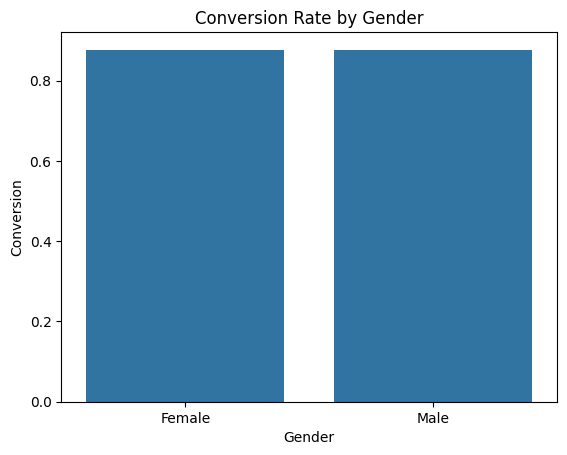

In [438]:
# 2. Gender vs Conversion
gender_conv = (
    df.groupby('Gender')['Conversion']
      .mean()
      .reset_index()
)

sns.barplot(data=gender_conv, x='Gender', y='Conversion')
plt.title('Conversion Rate by Gender')
plt.show()

### Engagement Analysis

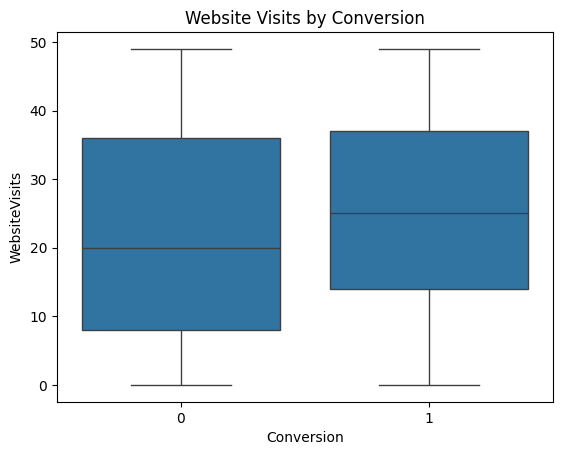

In [439]:
# 1. Website Visits vs Conversion

sns.boxplot(data=df, x='Conversion', y='WebsiteVisits')
plt.title('Website Visits by Conversion')
plt.show()

Converted customers have slightly higher website visits, but the large overlap suggests visits alone do not strongly determine conversions.

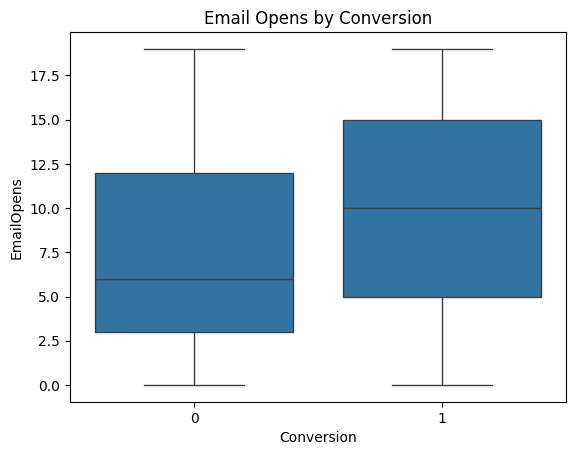

In [440]:
# 2. Email Opens vs Conversion

sns.boxplot(data=df, x='Conversion', y='EmailOpens')
plt.title('Email Opens by Conversion')
plt.show()

Converted customers tend to open more emails, indicating email engagement is positively associated with conversions.

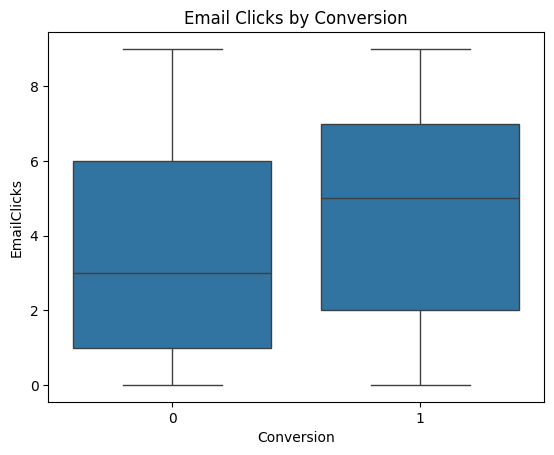

In [441]:
# 3. Email Clicks vs Conversion

sns.boxplot(data=df, x='Conversion', y='EmailClicks')
plt.title('Email Clicks by Conversion')
plt.show()

Converted users generally have more email clicks, suggesting click-through activity is a stronger indicator of conversion intent.

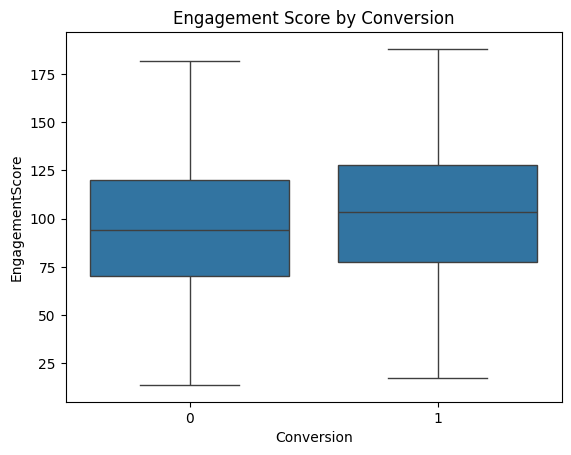

In [442]:
# 4. Engagement Score vs Conversion

sns.boxplot(data=df, x='Conversion', y='EngagementScore')
plt.title('Engagement Score by Conversion')
plt.show()

Converted customers exhibit higher engagement scores overall, implying that greater engagement increases the likelihood of conversion.

Email interactions (opens and clicks) show a stronger relationship with conversions than website visits, indicating that improving email engagement may be more effective than solely increasing website traffic.

#6. KPI Engineering

In [443]:
# we already have KPIs like CTR(click through rate), Conversion Rate
# for CPC(cost per click) we can find an approx value as we don't have clicks column
# CPC = Total Ad Spend / Total Clicks , but have to do something else


# 1. Estimated Clicks
df['Estimated_Clicks'] = (
    df['WebsiteVisits'] * df['ClickThroughRate']
)

# 2. Estimated CPC
# 0 clicks too needs to be taken care of
df['Estimated_CPC'] = np.where(
    df['Estimated_Clicks'] > 0,
    df['AdSpend'] / df['Estimated_Clicks'],
    np.nan
)

In [444]:
# 3. Total Conversion

total_conversions = df['Conversion'].sum()
print("Total Conversions:", total_conversions)

Total Conversions: 7012


In [445]:
# 4. Conversion Percentage

conversion_percentage = df['Conversion'].mean() * 100
print("Conversion Percentage:", round(conversion_percentage, 2), "%")

Conversion Percentage: 87.65 %


In [446]:
# 5. Customer acquisition cost

total_spend = df['AdSpend'].sum()

cac = (
    total_spend / total_conversions
    if total_conversions > 0
    else np.nan
)

print("CAC:", round(cac, 2))

CAC: 5705.58


In [447]:
# 6. Avg Ad spend

avg_ad_spend = df['AdSpend'].mean()
print("Average Ad Spend:", round(avg_ad_spend, 2))

Average Ad Spend: 5000.94


In [448]:
# 7. Engagement Score

df['EngagementScore'] = (
    df['WebsiteVisits']
    + df['PagesPerVisit']
    + df['TimeOnSite']
    + df['SocialShares']
    + df['EmailOpens']
    + df['EmailClicks']
)

In [449]:
# 8. Email Engagement Rate

df['EmailEngagementRate'] = np.where(
    df['EmailOpens'] > 0,
    df['EmailClicks'] / df['EmailOpens'],
    np.nan
)

In [450]:
pd.set_option('display.max_columns', None) #truncatin the columns to have a look at the table

In [451]:
df.head(2)

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion,EngagementScore,Age_Group,Estimated_Clicks,Estimated_CPC,EmailEngagementRate
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1,43.795819,46-60,0.000000,NaN,1.5
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1,64.269686,60+,6.540453,596.085411,3.5


### Key Insights from KPI Engineering
* The overall conversion rate is 87%, indicating that a large proportion of targeted customers converted successfully.
* On average, the company spends ₹5,705 to acquire one customer.
* The high conversion rate suggests that the marketing campaigns are performing well in attracting customers.
* These KPIs provide a foundation for further analysis of customer segments, campaign profitability, and budget allocation strategies

# 7. Customer Segmentation

In [452]:
features = [
    'Age',
    'Income',
    'AdSpend',
    'WebsiteVisits',
    'PagesPerVisit',
    'TimeOnSite',
    'EmailOpens',
    'EmailClicks'
]

In [453]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

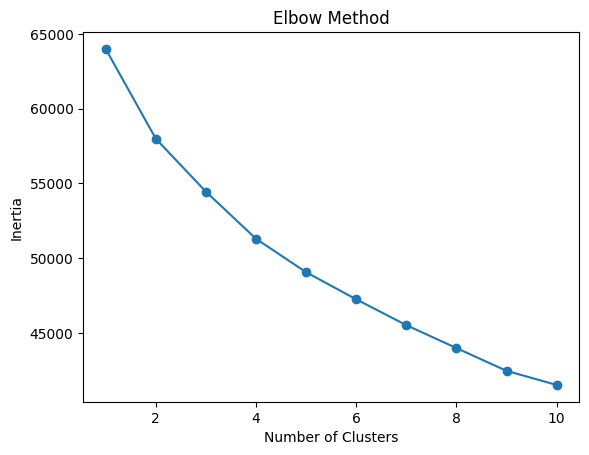

In [454]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [455]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [456]:
cluster_profile = (
    df.groupby('Cluster')[features + ['Conversion']]
      .mean()
      .round(2)
)

cluster_profile

,Age,Income,AdSpend,WebsiteVisits,PagesPerVisit,TimeOnSite,EmailOpens,EmailClicks,Conversion
Cluster,,,,,,,,,
0,53.73,85147.48,5252.87,35.72,5.51,7.36,10.13,2.54,0.88
1,32.79,81583.50,4885.29,15.12,5.73,8.55,8.87,2.27,0.83
2,54.93,86750.34,4840.33,14.33,5.68,8.12,9.85,6.41,0.89
3,32.60,85138.93,5019.25,33.62,5.28,6.88,9.03,6.69,0.91


In [457]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [458]:
with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

### Customer Segment Insights
* Cluster 0: Older customers with high ad spend and website visits, showing strong engagement and an 88% conversion rate.
* Cluster 1: Younger customers with lower engagement and the lowest conversion rate (83%), indicating scope for better targeting.
* Cluster 2: High-income, email-responsive customers with an 89% conversion rate, making them valuable for email campaigns.
* Cluster 3: Young, digitally engaged customers with the highest conversion rate (91%), representing the most promising customer segment.
### Business Recommendation
* Prioritize Cluster 3 for future campaigns.
* Retain and nurture Clusters 0 and 2.
* Improve engagement strategies for Cluster 1.

#8. Conversion Prediction Model (ML)

In [459]:
df['Conversion'].value_counts()

,count
Conversion,
1,7012
0,988


The target variable (Conversion) is imbalanced, with 7,012 converted customers (87.65%) and 988 non-converted customers (12.35%). Due to this imbalance, accuracy alone can be misleading, as a naive model predicting all customers as converted would already achieve nearly 88% accuracy. Therefore, model evaluation primarily focuses on ROC-AUC, F1-score, Precision, and Recall.

In [460]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  8000 non-null   int64   
 1   Gender               8000 non-null   object  
 2   Income               8000 non-null   int64   
 3   CampaignChannel      8000 non-null   object  
 4   CampaignType         8000 non-null   object  
 5   AdSpend              8000 non-null   float64 
 6   ClickThroughRate     8000 non-null   float64 
 7   ConversionRate       8000 non-null   float64 
 8   WebsiteVisits        8000 non-null   int64   
 9   PagesPerVisit        8000 non-null   float64 
 10  TimeOnSite           8000 non-null   float64 
 11  SocialShares         8000 non-null   int64   
 12  EmailOpens           8000 non-null   int64   
 13  EmailClicks          8000 non-null   int64   
 14  PreviousPurchases    8000 non-null   int64   
 15  LoyaltyPoints        

### encoding

In [461]:
categorical_cols = ['Gender', 'CampaignChannel', 'CampaignType', 'Age_Group']

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

encoder.fit(df[categorical_cols])

with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

In [462]:
with open('encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

In [463]:
encoded_data = encoder.transform(df[categorical_cols])

### Seperating target and feature variables

In [464]:
# Encoded column names
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Encoded dataframe
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_cols,
    index=df.index
)

# Original dataframe se categorical columns hatao
df_encoded = pd.concat(
    [df.drop(columns=categorical_cols), encoded_df],
    axis=1
)

In [465]:
X = df_encoded.drop(columns=['Conversion'])
y = df_encoded['Conversion']

In [466]:
imputer = SimpleImputer(strategy='median')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [467]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Training models

Three model are being compared: Logistic Regression, Random Forest Classifier, XGBoost.

Why Multiple Models?

Three algorithms were evaluated to compare linear and ensemble-based learning approaches and identify the model with the best predictive performance.

In [468]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss'
    )
}

In [469]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.701875   0.920837  0.721826  0.809276  0.675788
1        Random Forest  0.885000   0.885443  0.997860  0.938296  0.800595
2              XGBoost  0.913125   0.919601  0.987161  0.952184  0.806543


Three classification models—Logistic Regression, Random Forest, and XGBoost—were evaluated. XGBoost achieved the highest Accuracy (91.3%), F1 Score (95.2%), and ROC-AUC (0.807). Therefore, XGBoost was selected as the final model for deployment because it provided the best overall balance between correctly identifying conversions and minimizing misclassifications.

In [470]:
best_model = models['XGBoost']

# 9. Hyperparameter Tuning (RandomizedSearchCV)

In [471]:
# Define parameter search space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


In [472]:
# Randomized Search
random_search = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [473]:
# Train the tuner
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='accuracy')

In [474]:
# Best tuned model
best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(random_search.best_score_, 4))

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best Cross Validation Accuracy:
0.9206


In [475]:
# Tuned model ko native XGBoost format me save karo (pickle ki jagah)
best_model.save_model("model.json")

import json
with open("feature_names.json", "w") as f:
    json.dump(X.columns.tolist(), f)

print("Tuned model saved successfully in JSON format!")

Tuned model saved successfully in JSON format!


# 10. Cross Validation

To evaluate the robustness and generalization capability of the selected XGBoost model, **5-Fold Cross Validation** was performed. This provides a more reliable estimate of model performance by evaluating it across multiple train-test splits.

In [476]:
# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Accuracy Scores: [0.95     0.9375   0.938125 0.898125 0.866875]
Mean Accuracy: 0.9181250000000001
Standard Deviation: 0.031041806487380863


Across 5 different train-test combinations, the model achieved an average accuracy of 90.9%, indicating consistent performance.

#11. Model Interpretability using Feature Importance

In [477]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
10,EmailClicks,0.083371
24,CampaignType_Conversion,0.080028
11,PreviousPurchases,0.077601
9,EmailOpens,0.059328
7,TimeOnSite,0.056295
6,PagesPerVisit,0.053385
2,AdSpend,0.052090
4,ConversionRate,0.050757
14,Estimated_Clicks,0.046952
12,LoyaltyPoints,0.044444


In [478]:
top_features = feature_importance.head(10)

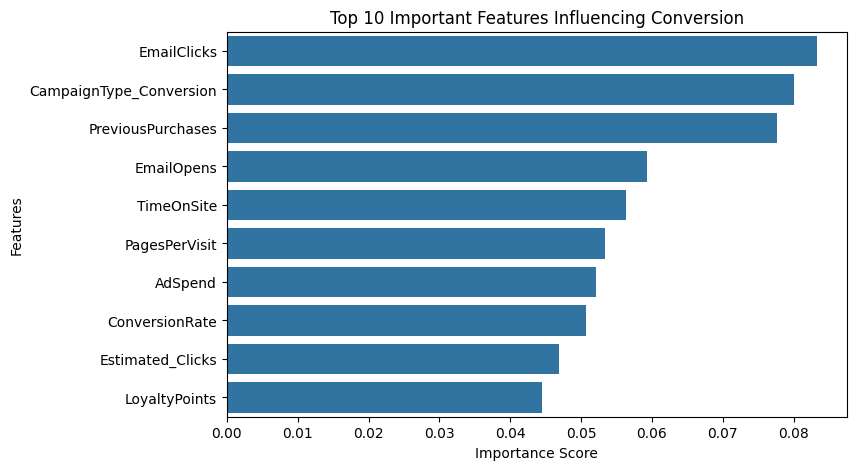

In [479]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)
plt.title('Top 10 Important Features Influencing Conversion')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 12. SHAP Explainability

Why Explainability?

Business stakeholders require not only predictions but also an understanding of the factors influencing those predictions.

In [480]:
explainer = shap.TreeExplainer(best_model)

In [481]:
shap_values = explainer(X_test)

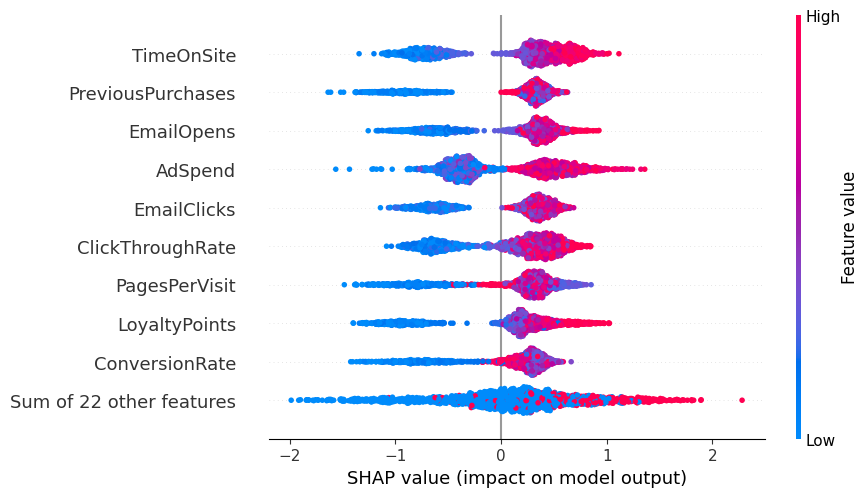

In [482]:
shap.plots.beeswarm(shap_values, max_display=10)

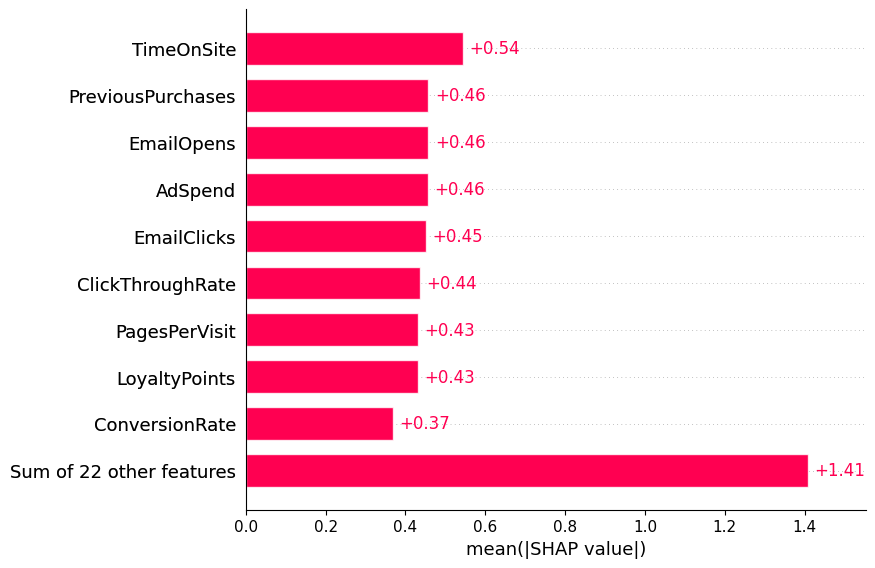

In [483]:
shap.plots.bar(shap_values, max_display=10)

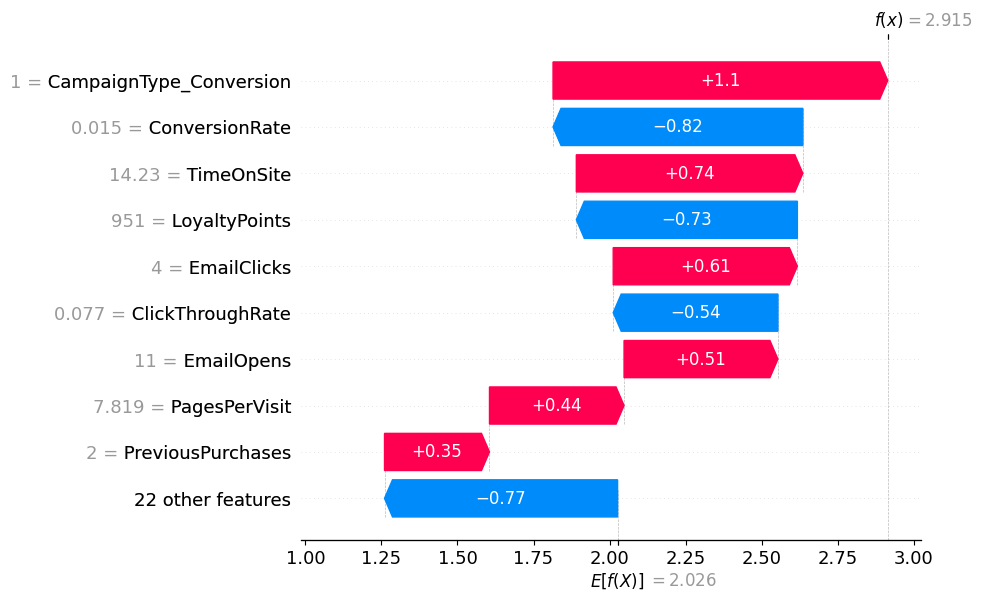

In [484]:
sample_index = 0

shap.plots.waterfall(shap_values[sample_index])

#13. Buissness Recommendation

### 1. Prioritize High-Converting Marketing Channels

The analysis shows that **Referral campaigns achieved the highest average conversion rate (88.31%)**, closely followed by **PPC campaigns (88.28%)**. In comparison, Social Media and Email campaigns produced slightly lower conversion rates.

**Recommendation:**
- Allocate a larger share of the marketing budget toward Referral and PPC campaigns.
- Continue investing in SEO as a stable acquisition channel.
- Reassess spending on lower-performing channels to improve overall marketing efficiency.

### 2. Increase Investment in Conversion-Oriented Campaigns

Among all campaign objectives, **Conversion campaigns achieved an average conversion rate of 93.36%**, substantially outperforming Awareness, Consideration, and Retention campaigns (≈85–86%).

**Recommendation:**
- Prioritize Conversion campaigns for customers already in the decision stage.
- Use Awareness and Consideration campaigns primarily for lead generation before moving prospects into conversion-focused campaigns.

### 3. Improve Customer Engagement Before Conversion

The analysis indicates that customers who spend more time on the website are more likely to convert. **Time on Site** emerged as one of the strongest positive indicators of successful conversion.

**Recommendation:**
- Improve landing page quality.
- Reduce page load time.
- Provide personalized content and product recommendations.
- Encourage deeper website exploration through internal linking and engaging CTAs.


### 4. Optimize Click-Through Performance

The correlation analysis suggests that **Click Through Rate (CTR)** positively influences campaign conversions.

**Recommendation:**
- Continuously A/B test advertisement creatives.
- Improve ad headlines and visuals.
- Optimize audience targeting to improve CTR and overall campaign effectiveness.

### 5. Reward Existing Customers

Customers with **higher Previous Purchases** and **greater Loyalty Points** demonstrated better conversion behavior.

**Recommendation:**
- Invest in customer retention programs.
- Launch exclusive offers for repeat customers.
- Expand loyalty rewards to encourage recurring purchases and increase customer lifetime value.


### 6. Allocate Budget Based on Performance Rather Than Equal Distribution

The analysis suggests that increasing spending alone is not sufficient; budget should be directed toward channels and campaign types with consistently higher conversion performance.

**Recommendation:**
- Shift budget toward high-performing campaign-channel combinations.
- Monitor ROI regularly and rebalance spending using campaign performance metrics instead of fixed budget allocation.

# 14. Save, Load and Verify the Trained Model

In [485]:
import json

# Tuned model ko native XGBoost format me save karo
best_model.save_model("model.json")

# Feature names alag se save karo
with open("feature_names.json", "w") as f:
    json.dump(X.columns.tolist(), f)

print("Model aur feature names save ho gaye!")

Model aur feature names save ho gaye!


In [486]:
import xgboost as xgb

loaded_model = xgb.XGBClassifier()
loaded_model.load_model("model.json")

with open("feature_names.json") as f:
    feature_names = json.load(f)

y_pred_loaded = loaded_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_loaded)
print(f"Loaded Model Accuracy: {accuracy:.4f}")

Loaded Model Accuracy: 0.9237


#  Project Limitations

- The dataset used in this project is relatively clean and may not fully represent the complexity of real-world marketing data.

- This analysis is based on historical campaign data. Customer behavior and market trends can change over time, which may affect the model's performance.

- The model predictions depend only on the features available in the dataset. Other factors such as competitor strategies, seasonal trends, economic conditions, and customer preferences were not included.

- Although the model performs well on the given dataset, its performance should be validated on new and unseen real-world data before business deployment.

- The budget optimization recommendations are based on patterns identified in the dataset and should be used as decision support rather than as fixed business rules.

- This project focuses on prediction and analysis. It does not include real-time data processing or automatic campaign optimization.

#  Project Outcomes

- Successfully analyzed digital marketing campaign data to identify the key factors affecting customer conversions.

- Built and compared multiple machine learning models to predict campaign success and selected the best-performing model after hyperparameter tuning.

- Identified the most influential features affecting conversion using Feature Importance and SHAP, making the model more transparent and easier to interpret.

- Discovered that Referral and PPC campaigns achieved the highest average conversion rates, while Conversion campaigns performed significantly better than other campaign objectives.

- Generated data-driven business recommendations to help optimize marketing budget allocation and improve campaign performance.

- Developed a complete end-to-end machine learning workflow, including data preprocessing, feature engineering, model training, evaluation, explainability, and model saving for future deployment.